In [24]:
import os
import numpy as np
import h5py
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

In [25]:
# ── 通道定義 ──
CH_NAMES = [
    'Fp1','Fz','F3','F7','FT9','FC5','FC1',   # 0-6
    'C3','T7','TP9','CP5','CP1','Pz','P3','P7', # 7-14
    'O1','Oz','O2',                              # 15-17
    'P4','P8','TP10','CP6','CP2','Cz','C4','T8', # 18-25
    'FT10','FC6','FC2','F4','F8','Fp2'           # 26-31
]

# 五腦區分組
REGIONS = {
    'Frontal':   [0, 31, 2, 29, 3, 30, 1],               # Fp1,Fp2,F3,F4,F7,F8,Fz (7ch)
    'Central':   [7, 24, 23, 6, 28, 5, 27],               # C3,C4,Cz,FC1,FC2,FC5,FC6 (7ch)
    'Parietal':  [13, 18, 14, 19, 12, 11, 22, 10, 21],    # P3,P4,P7,P8,Pz,CP1,CP2,CP5,CP6 (9ch)
    'Temporal':  [8, 25, 4, 26, 9, 20],                   # T7,T8,FT9,FT10,TP9,TP10 (6ch)
    'Occipital': [15, 17, 16],                             # O1,O2,Oz (3ch)
}

for name, chs in REGIONS.items():
    ch_names = [CH_NAMES[i] for i in chs]
    print(f'{name} ({len(chs)}ch): {ch_names}')

# 驗證：32ch 全部涵蓋且不重複
all_ch = sum(REGIONS.values(), [])
assert sorted(all_ch) == list(range(32)), '通道分組有誤！'

Frontal (7ch): ['Fp1', 'Fp2', 'F3', 'F4', 'F7', 'F8', 'Fz']
Central (7ch): ['C3', 'C4', 'Cz', 'FC1', 'FC2', 'FC5', 'FC6']
Parietal (9ch): ['P3', 'P4', 'P7', 'P8', 'Pz', 'CP1', 'CP2', 'CP5', 'CP6']
Temporal (6ch): ['T7', 'T8', 'FT9', 'FT10', 'TP9', 'TP10']
Occipital (3ch): ['O1', 'O2', 'Oz']


In [26]:
# ── 資料載入 ──

def get_subject_id(filename):
    return filename.split('_ses-')[0]

def scan_session_folder(folder_path):
    result = {}
    for fname in sorted(os.listdir(folder_path)):
        if fname.endswith('.mat'):
            result[get_subject_id(fname)] = os.path.join(folder_path, fname)
    return result

def load_band_energy(filepath):
    with h5py.File(filepath, 'r') as f:
        data = np.array(f['band_energy']).T
    return data

def load_group(ss01_map, ss02_map, ss03_map, complete_subs):
    X1, X2, X3 = [], [], []
    for sub_id in complete_subs:
        X1.append(load_band_energy(ss01_map[sub_id]))
        X2.append(load_band_energy(ss02_map[sub_id]))
        X3.append(load_band_energy(ss03_map[sub_id]))
    return np.array(X1), np.array(X2), np.array(X3)

BASE_AMATEUR = r'D:\Tseng\圍棋\amateur\band_energy_batch_outputs_2026'
BASE_MASTER  = r'D:\Tseng\圍棋\master\band_energy_batch_outputs_2026'
BASE_PROF    = r'D:\Tseng\圍棋\prof\band_energy_batch_outputs_2026'

PATHS = {
    'amateur': {s: os.path.join(BASE_AMATEUR, s) for s in ['ss01','ss02','ss03']},
    'master':  {s: os.path.join(BASE_MASTER,  s) for s in ['ss01','ss02','ss03']},
    'prof':    {s: os.path.join(BASE_PROF,    s) for s in ['ss01','ss02','ss03']},
}

maps = {}
complete = {}
for group in ['amateur', 'master', 'prof']:
    m1 = scan_session_folder(PATHS[group]['ss01'])
    m2 = scan_session_folder(PATHS[group]['ss02'])
    m3 = scan_session_folder(PATHS[group]['ss03'])
    maps[group] = (m1, m2, m3)
    complete[group] = sorted(set(m1) & set(m2) & set(m3))
    print(f'[{group}] 完整 subject：{len(complete[group])} 人')

print('\n載入資料...')
X_a1, X_a2, X_a3 = load_group(*maps['amateur'], complete['amateur'])
X_m1, X_m2, X_m3 = load_group(*maps['master'],  complete['master'])
X_p1, X_p2, X_p3 = load_group(*maps['prof'],    complete['prof'])
print(f'完成  shape: {X_a1.shape}  (n_sub, 32ch, 39time, 5bands)')

[amateur] 完整 subject：28 人
[master] 完整 subject：20 人
[prof] 完整 subject：8 人

載入資料...
完成  shape: (28, 32, 39, 5)  (n_sub, 32ch, 39time, 5bands)


In [27]:
# ── 特徵提取 & LOSO 準備 ──

CLASS_NAMES = ['amateur', 'master', 'prof']

def extract_mean_3d(X):
    """(n, 32ch, 39time, 5bands) → (n, 32, 5)"""
    X = np.log(X + 1e-8)
    X = X[:, :, 1:-1, :]
    return X.mean(axis=2)

n_a = len(complete['amateur'])
n_m = len(complete['master'])
n_p = len(complete['prof'])
n_total = n_a + n_m + n_p

raw = {
    'amateur': [X_a1, X_a2, X_a3],
    'master':  [X_m1, X_m2, X_m3],
    'prof':    [X_p1, X_p2, X_p3],
}

feats_3d = []
for g in CLASS_NAMES:
    for Xr in raw[g]:
        feats_3d.append(extract_mean_3d(Xr))
X_3d = np.vstack(feats_3d)  # (168, 32, 5)

y_all = np.concatenate([np.zeros(n_a * 3), np.ones(n_m * 3), np.full(n_p * 3, 2)])
subject_ids = complete['amateur'] + complete['master'] + complete['prof']
subject_split = np.concatenate([
    np.repeat(complete['amateur'], 3),
    np.repeat(complete['master'], 3),
    np.repeat(complete['prof'], 3),
])
subject_labels = {}
for g_idx, g in enumerate(CLASS_NAMES):
    for s in complete[g]:
        subject_labels[s] = g_idx

print(f'X_3d shape: {X_3d.shape}')
print(f'Total subjects: {n_total}  (Amateur: {n_a}, Master: {n_m}, Prof: {n_p})')

X_3d shape: (168, 32, 5)
Total subjects: 56  (Amateur: 28, Master: 20, Prof: 8)


In [28]:
# ── 五腦區 LOSO（PCA 95% explained variance）──

region_results = {}

for region_name, ch_idx in REGIONS.items():
    n_ch = len(ch_idx)
    dims = n_ch * 5

    X_feat = X_3d[:, ch_idx, :].reshape(len(X_3d), -1)

    all_preds, all_true = [], []
    per_sub = []
    pca_dims_list = []

    for test_subject in subject_ids:
        test_mask  = subject_split == test_subject
        train_mask = ~test_mask

        X_tr, y_tr = X_feat[train_mask], y_all[train_mask].astype(int)
        X_te, y_te = X_feat[test_mask],  y_all[test_mask].astype(int)

        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_tr)
        X_te = scaler.transform(X_te)

        pca = PCA(n_components=0.95)
        X_tr = pca.fit_transform(X_tr)
        X_te = pca.transform(X_te)
        pca_dims_list.append(pca.n_components_)

        clf = SVC(kernel='rbf', C=10, gamma='scale',
                  class_weight='balanced', random_state=42)
        clf.fit(X_tr, y_tr)
        preds = clf.predict(X_te)

        acc = accuracy_score(y_te, preds)
        f1  = f1_score(y_te, preds, average='macro', zero_division=0)
        per_sub.append({'acc': acc, 'f1': f1, 'subject': test_subject,
                        'true': subject_labels[test_subject]})
        all_preds.extend(preds)
        all_true.extend(y_te)

    all_preds = np.array(all_preds)
    all_true  = np.array(all_true)
    mean_acc = np.mean([r['acc'] for r in per_sub])
    mean_f1  = f1_score(all_true, all_preds, average='macro', zero_division=0)
    pca_n = int(np.median(pca_dims_list))

    region_results[region_name] = {
        'acc': mean_acc, 'f1': mean_f1, 'dims': dims, 'pca': pca_n,
        'preds': all_preds, 'true': all_true, 'per_sub': per_sub,
        'ch_idx': ch_idx,
    }

    print(f'[{region_name:<13s}] {n_ch:2d}ch × 5bands = {dims:3d} dims  '
          f'PCA(95%)→{pca_n:2d}  Acc={mean_acc:.3f}  F1={mean_f1:.3f}')

[Frontal      ]  7ch × 5bands =  35 dims  PCA(95%)→ 7  Acc=0.643  F1=0.615
[Central      ]  7ch × 5bands =  35 dims  PCA(95%)→ 8  Acc=0.601  F1=0.575
[Parietal     ]  9ch × 5bands =  45 dims  PCA(95%)→ 7  Acc=0.708  F1=0.691
[Temporal     ]  6ch × 5bands =  30 dims  PCA(95%)→ 6  Acc=0.577  F1=0.555
[Occipital    ]  3ch × 5bands =  15 dims  PCA(95%)→ 4  Acc=0.500  F1=0.492


In [29]:
# ── Save region results for cross-notebook comparison ──
import json
_out = {rn: {'acc': float(r['acc']), 'f1': float(r['f1'])}
        for rn, r in region_results.items()}
_out_path = r'D:\Tseng\game_eeg\SVM_BE\svm_band_energy_results.json'
with open(_out_path, 'w', encoding='utf-8') as _f:
    json.dump(_out, _f, indent=2)
print(f'Saved → {_out_path}')
print(_out)

Saved → D:\Tseng\game_eeg\SVM_BE\svm_band_energy_results.json
{'Frontal': {'acc': 0.6428571428571429, 'f1': 0.6152674283821825}, 'Central': {'acc': 0.6011904761904762, 'f1': 0.5754699864213139}, 'Parietal': {'acc': 0.7083333333333333, 'f1': 0.6905402268705668}, 'Temporal': {'acc': 0.5773809523809523, 'f1': 0.5545892150579136}, 'Occipital': {'acc': 0.5, 'f1': 0.4924566984800283}}


In [30]:
# ── 比較表格 ──

print('=' * 70)
print('SVM 3-Class LOSO — 五腦區比較')
print('=' * 70)
print(f'{"Region":<15s} {"Channels":>4s} {"Dims":>5s} {"PCA":>5s} {"Acc":>8s} {"F1":>8s}')
print('-' * 50)
for name, r in region_results.items():
    n_ch = len(r['ch_idx'])
    print(f'{name:<15s} {n_ch:4d} {r["dims"]:5d} {r["pca"]:5d} {r["acc"]:8.3f} {r["f1"]:8.3f}')
print('=' * 70)

SVM 3-Class LOSO — 五腦區比較
Region          Channels  Dims   PCA      Acc       F1
--------------------------------------------------
Frontal            7    35     7    0.643    0.615
Central            7    35     8    0.601    0.575
Parietal           9    45     7    0.708    0.691
Temporal           6    30     6    0.577    0.555
Occipital          3    15     4    0.500    0.492


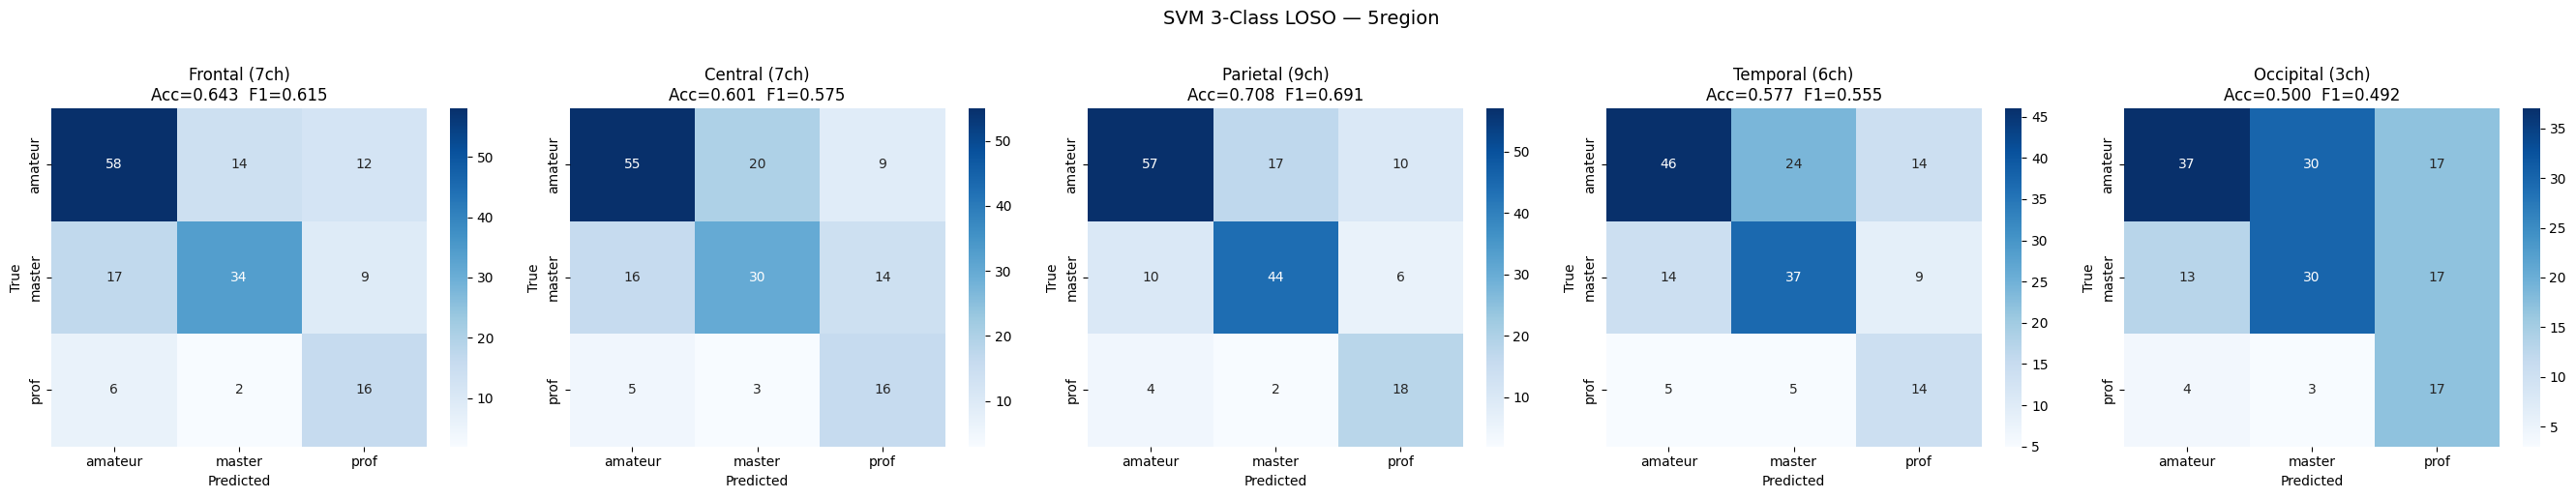

In [31]:
# ── 五腦區混淆矩陣 ──

fig, axes = plt.subplots(1, 5, figsize=(27, 5))

for ax, (region_name, r) in zip(axes, region_results.items()):
    cm = confusion_matrix(r['true'], r['preds'], labels=[0, 1, 2])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    n_ch = len(r['ch_idx'])
    ax.set_title(f'{region_name} ({n_ch}ch)\nAcc={r["acc"]:.3f}  F1={r["f1"]:.3f}')

plt.suptitle('SVM 3-Class LOSO — 5region', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(r'D:\Tseng\game_eeg\SVM_BE\svm_band_energy_confusion.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [32]:
# ── 各腦區 Classification Report ──

for region_name, r in region_results.items():
    n_ch = len(r['ch_idx'])
    print(f'\n{"="*60}')
    print(f'{region_name} ({n_ch}ch)  Acc={r["acc"]:.3f}  F1={r["f1"]:.3f}')
    print(f'{"="*60}')
    print(classification_report(r['true'], r['preds'],
                                target_names=CLASS_NAMES, zero_division=0))


Frontal (7ch)  Acc=0.643  F1=0.615
              precision    recall  f1-score   support

     amateur       0.72      0.69      0.70        84
      master       0.68      0.57      0.62        60
        prof       0.43      0.67      0.52        24

    accuracy                           0.64       168
   macro avg       0.61      0.64      0.62       168
weighted avg       0.66      0.64      0.65       168


Central (7ch)  Acc=0.601  F1=0.575
              precision    recall  f1-score   support

     amateur       0.72      0.65      0.69        84
      master       0.57      0.50      0.53        60
        prof       0.41      0.67      0.51        24

    accuracy                           0.60       168
   macro avg       0.57      0.61      0.58       168
weighted avg       0.62      0.60      0.61       168


Parietal (9ch)  Acc=0.708  F1=0.691
              precision    recall  f1-score   support

     amateur       0.80      0.68      0.74        84
      master       0

In [33]:
# ── Per-subject 正確率 (按腦區) ──

print(f'{"":<12s}', end='')
for rn in REGIONS:
    print(f'{rn:>15s}', end='')
print()
print('-' * 72)

for sub in subject_ids:
    grp = CLASS_NAMES[subject_labels[sub]]
    print(f'{sub:<10s}({grp[0]})', end='')
    for rn in REGIONS:
        r = region_results[rn]
        sub_res = [s for s in r['per_sub'] if s['subject'] == sub][0]
        print(f'{sub_res["acc"]:15.3f}', end='')
    print()

                    Frontal        Central       Parietal       Temporal      Occipital
------------------------------------------------------------------------
sub-22    (a)          0.333          1.000          0.667          0.333          0.333
sub-23    (a)          1.000          0.333          0.667          0.667          0.667
sub-24    (a)          0.333          1.000          1.000          0.667          0.667
sub-33    (a)          0.667          0.333          0.333          0.667          0.000
sub-38    (a)          0.667          0.667          0.667          0.333          0.667
sub-39    (a)          0.667          0.667          0.333          0.333          0.667
sub-40    (a)          1.000          0.667          0.667          0.333          0.333
sub-41    (a)          0.667          0.667          1.000          1.000          0.667
sub-42    (a)          1.000          0.667          0.667          0.333          0.667
sub-43    (a)          0.333          

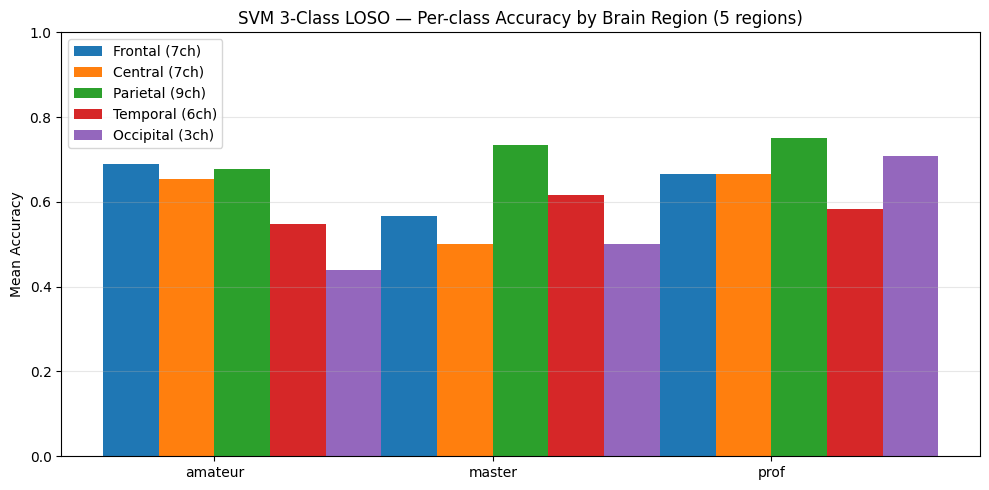

In [34]:
# ── 各腦區 per-class 正確率 bar chart ──

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(CLASS_NAMES))
width = 0.2

for i, (region_name, r) in enumerate(region_results.items()):
    per_class_acc = []
    for cls_idx in range(3):
        cls_subs = [s for s in r['per_sub'] if s['true'] == cls_idx]
        per_class_acc.append(np.mean([s['acc'] for s in cls_subs]))
    n_ch = len(r['ch_idx'])
    ax.bar(x + i * width, per_class_acc, width,
           label=f'{region_name} ({n_ch}ch)')

ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels(CLASS_NAMES)
ax.set_ylabel('Mean Accuracy')
ax.set_title('SVM 3-Class LOSO — Per-class Accuracy by Brain Region (5 regions)')
ax.legend()
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(r'D:\Tseng\game_eeg\SVM_BE\svm_band_energy_per_class.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [35]:
# ── 全 32ch 合併 vs 各腦區：特徵獨立性驗證（PCA 95%）──

all_ch = list(range(32))
dims_all = 32 * 5

X_feat_all = X_3d[:, all_ch, :].reshape(len(X_3d), -1)

all_preds, all_true = [], []
per_sub_all = []
pca_dims_list = []

for test_subject in subject_ids:
    test_mask  = subject_split == test_subject
    train_mask = ~test_mask

    X_tr, y_tr = X_feat_all[train_mask], y_all[train_mask].astype(int)
    X_te, y_te = X_feat_all[test_mask],  y_all[test_mask].astype(int)

    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_tr)
    X_te = scaler.transform(X_te)

    pca = PCA(n_components=0.95)
    X_tr = pca.fit_transform(X_tr)
    X_te = pca.transform(X_te)
    pca_dims_list.append(pca.n_components_)

    clf = SVC(kernel='rbf', C=10, gamma='scale',
              class_weight='balanced', random_state=42)
    clf.fit(X_tr, y_tr)
    preds = clf.predict(X_te)

    acc = accuracy_score(y_te, preds)
    f1  = f1_score(y_te, preds, average='macro', zero_division=0)
    per_sub_all.append({'acc': acc, 'f1': f1, 'subject': test_subject,
                        'true': subject_labels[test_subject]})
    all_preds.extend(preds)
    all_true.extend(y_te)

acc_all = np.mean([r['acc'] for r in per_sub_all])
f1_all  = f1_score(np.array(all_true), np.array(all_preds), average='macro', zero_division=0)
pca_all = int(np.median(pca_dims_list))

# 比較表
best_single = max(region_results.values(), key=lambda r: r['acc'])
best_name = [k for k, v in region_results.items() if v is best_single][0]

print('=' * 70)
print('特徵獨立性驗證：全 32ch 合併 vs 各腦區 (PCA 95%)')
print('=' * 70)
print(f'{"Region":<15s} {"Channels":>4s} {"Dims":>5s} {"PCA":>5s} {"Acc":>8s} {"F1":>8s}')
print('-' * 50)
for name, r in region_results.items():
    n_ch = len(r['ch_idx'])
    print(f'{name:<15s} {n_ch:4d} {r["dims"]:5d} {r["pca"]:5d} {r["acc"]:8.3f} {r["f1"]:8.3f}')
print('-' * 50)
print(f'{"ALL_32ch":<15s} {32:4d} {dims_all:5d} {pca_all:5d} {acc_all:8.3f} {f1_all:8.3f}')
print('=' * 70)

diff = acc_all - best_single['acc']
print(f'\nBest single region: {best_name} (Acc={best_single["acc"]:.3f})')
print(f'ALL_32ch:           Acc={acc_all:.3f}  (diff = {diff:+.3f})')
if diff > 0.02:
    print('→ 合併後明顯提升，各腦區特徵具有互補性（相對獨立）')
elif diff > -0.02:
    print('→ 合併後表現相當，各腦區特徵有部分冗餘')
else:
    print('→ 合併後反而下降，各腦區特徵高度冗餘，合併增加雜訊')

特徵獨立性驗證：全 32ch 合併 vs 各腦區 (PCA 95%)
Region          Channels  Dims   PCA      Acc       F1
--------------------------------------------------
Frontal            7    35     7    0.643    0.615
Central            7    35     8    0.601    0.575
Parietal           9    45     7    0.708    0.691
Temporal           6    30     6    0.577    0.555
Occipital          3    15     4    0.500    0.492
--------------------------------------------------
ALL_32ch          32   160    16    0.744    0.742

Best single region: Parietal (Acc=0.708)
ALL_32ch:           Acc=0.744  (diff = +0.036)
→ 合併後明顯提升，各腦區特徵具有互補性（相對獨立）


In [36]:
# ── Band Ablation @ Parietal (BE only) — 設定 ──
from itertools import combinations

BAND_NAMES = ['delta', 'theta', 'alpha', 'beta', 'gamma']
TARGET_REGION = 'Parietal'
TARGET_CH_IDX = REGIONS[TARGET_REGION]
print(f'Target: {TARGET_REGION} ({len(TARGET_CH_IDX)} ch)')

def evaluate_be_band_subset(band_idx, ch_idx=TARGET_CH_IDX):
    """X_3d: (168, 32, 5). Pick channels and bands -> flatten -> LOSO with same pipeline."""
    X_feat = X_3d[:, ch_idx, :][:, :, band_idx].reshape(len(X_3d), -1)
    all_preds, all_true = [], []
    pca_dims = []
    for test_subject in subject_ids:
        m = subject_split == test_subject
        X_tr, y_tr = X_feat[~m], y_all[~m].astype(int)
        X_te, y_te = X_feat[m],  y_all[m].astype(int)
        sc = StandardScaler().fit(X_tr)
        X_tr, X_te = sc.transform(X_tr), sc.transform(X_te)
        pca = PCA(n_components=0.95).fit(X_tr)
        X_tr, X_te = pca.transform(X_tr), pca.transform(X_te)
        pca_dims.append(pca.n_components_)
        clf = SVC(kernel='rbf', C=10, gamma='scale',
                  class_weight='balanced', random_state=42)
        clf.fit(X_tr, y_tr)
        all_preds.extend(clf.predict(X_te))
        all_true.extend(y_te)
    all_preds, all_true = np.array(all_preds), np.array(all_true)
    return {
        'acc':  accuracy_score(all_true, all_preds),
        'f1':   f1_score(all_true, all_preds, average='macro', zero_division=0),
        'dims': X_feat.shape[1],
        'pca':  int(np.median(pca_dims)),
    }

# Baseline: 全 5 個 band
print('Baseline (all 5 bands)...')
baseline = evaluate_be_band_subset(list(range(5)))
print(f'  Acc={baseline["acc"]:.3f}  F1={baseline["f1"]:.3f}  '
      f'dims={baseline["dims"]} -> PCA{baseline["pca"]}')

Target: Parietal (9 ch)
Baseline (all 5 bands)...
  Acc=0.708  F1=0.691  dims=45 -> PCA7


In [37]:
# ── 分析 1: Leave-One-Band-Out (LOBO) ──
lobo_results = {}
print('=' * 78)
print(f'LOBO @ {TARGET_REGION} (BE only) — baseline Acc={baseline["acc"]:.3f}')
print('=' * 78)
print(f'{"Removed":<10s} {"Kept":<35s} {"Acc":>7s} {"dAcc":>7s} {"F1":>7s} {"dF1":>7s}')
print('-' * 78)
for drop_i, drop_name in enumerate(BAND_NAMES):
    keep_idx = [i for i in range(5) if i != drop_i]
    keep_names = [BAND_NAMES[i] for i in keep_idx]
    res = evaluate_be_band_subset(keep_idx)
    lobo_results[drop_name] = res
    d_acc = res['acc'] - baseline['acc']
    d_f1  = res['f1']  - baseline['f1']
    print(f'{drop_name:<10s} {",".join(keep_names):<35s} '
          f'{res["acc"]:7.3f} {d_acc:+7.3f} {res["f1"]:7.3f} {d_f1:+7.3f}')
print('=' * 78)
print('解讀: dAcc 越負 -> 拿掉該 band 後掉越多 -> 該 band 越重要')

LOBO @ Parietal (BE only) — baseline Acc=0.708
Removed    Kept                                    Acc    dAcc      F1     dF1
------------------------------------------------------------------------------
delta      theta,alpha,beta,gamma                0.714  +0.006   0.694  +0.003
theta      delta,alpha,beta,gamma                0.696  -0.012   0.695  +0.004
alpha      delta,theta,beta,gamma                0.690  -0.018   0.669  -0.022
beta       delta,theta,alpha,gamma               0.690  -0.018   0.677  -0.013
gamma      delta,theta,alpha,beta                0.679  -0.030   0.653  -0.038
解讀: dAcc 越負 -> 拿掉該 band 後掉越多 -> 該 band 越重要


In [38]:
# ── 分析 2: Single-Band only ──
single_results = {}
print('=' * 60)
print(f'Single-Band @ {TARGET_REGION} (BE only)')
print('=' * 60)
print(f'{"Band":<10s} {"dims":>6s} {"PCA":>5s} {"Acc":>7s} {"F1":>7s}')
print('-' * 60)
for i, name in enumerate(BAND_NAMES):
    res = evaluate_be_band_subset([i])
    single_results[name] = res
    print(f'{name:<10s} {res["dims"]:>6d} {res["pca"]:>5d} '
          f'{res["acc"]:7.3f} {res["f1"]:7.3f}')
print('=' * 60)

Single-Band @ Parietal (BE only)
Band         dims   PCA     Acc      F1
------------------------------------------------------------
delta           9     3   0.452   0.418
theta           9     2   0.548   0.529
alpha           9     3   0.488   0.458
beta            9     3   0.488   0.448
gamma           9     5   0.482   0.483


In [39]:
# ── 分析 3: 所有 31 種非空 band 子集 ──
all_subsets = []
for k in range(1, 6):
    for combo in combinations(range(5), k):
        all_subsets.append(list(combo))

print(f'總共 {len(all_subsets)} 種 band 子集, 跑 LOSO 中...')
subset_results = []
for idx, subset in enumerate(all_subsets):
    names = [BAND_NAMES[i] for i in subset]
    res = evaluate_be_band_subset(subset)
    res['subset'] = subset; res['names'] = names; res['k'] = len(subset)
    subset_results.append(res)
    print(f'  [{idx+1:2d}/31] k={len(subset)}  {",".join(names):<35s}  '
          f'Acc={res["acc"]:.3f}  F1={res["f1"]:.3f}')

subset_results_sorted = sorted(subset_results, key=lambda r: (-r['acc'], r['k']))

print('\n' + '=' * 78)
print('Top 10 子集 (依 Acc 排序, 同 Acc 偏好較少 band)')
print('=' * 78)
print(f'{"Rank":<5s} {"k":<3s} {"Bands":<35s} {"Acc":>7s} {"F1":>7s} {"dAcc":>8s}')
print('-' * 78)
for rank, r in enumerate(subset_results_sorted[:10], 1):
    d_acc = r['acc'] - baseline['acc']
    print(f'{rank:<5d} {r["k"]:<3d} {",".join(r["names"]):<35s} '
          f'{r["acc"]:7.3f} {r["f1"]:7.3f} {d_acc:+8.3f}')
print('=' * 78)

總共 31 種 band 子集, 跑 LOSO 中...
  [ 1/31] k=1  delta                                Acc=0.452  F1=0.418
  [ 2/31] k=1  theta                                Acc=0.548  F1=0.529
  [ 3/31] k=1  alpha                                Acc=0.488  F1=0.458
  [ 4/31] k=1  beta                                 Acc=0.488  F1=0.448
  [ 5/31] k=1  gamma                                Acc=0.482  F1=0.483
  [ 6/31] k=2  delta,theta                          Acc=0.536  F1=0.500
  [ 7/31] k=2  delta,alpha                          Acc=0.637  F1=0.627
  [ 8/31] k=2  delta,beta                           Acc=0.548  F1=0.508
  [ 9/31] k=2  delta,gamma                          Acc=0.577  F1=0.588
  [10/31] k=2  theta,alpha                          Acc=0.565  F1=0.542
  [11/31] k=2  theta,beta                           Acc=0.560  F1=0.521
  [12/31] k=2  theta,gamma                          Acc=0.607  F1=0.597
  [13/31] k=2  alpha,beta                           Acc=0.583  F1=0.547
  [14/31] k=2  alpha,gamma         

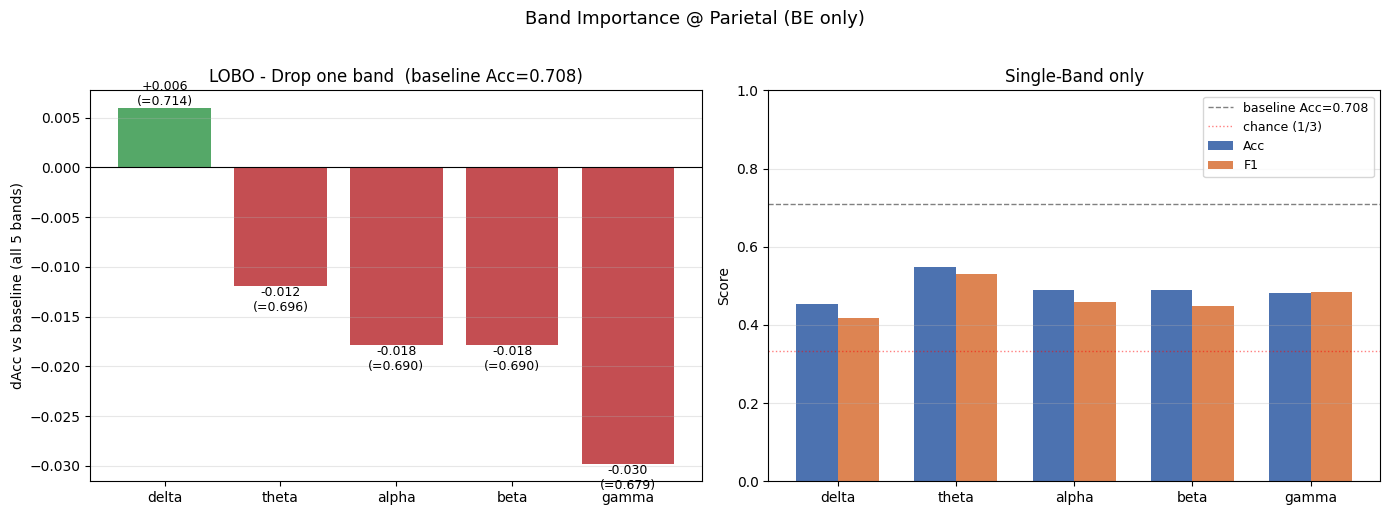

In [40]:
# ── 視覺化 1: LOBO + Single-Band Bar Chart ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(BAND_NAMES))

# LOBO
ax = axes[0]
lobo_acc = [lobo_results[b]['acc'] for b in BAND_NAMES]
delta_acc = [a - baseline['acc'] for a in lobo_acc]
colors = ['#C44E52' if d < 0 else '#55A868' for d in delta_acc]
bars = ax.bar(x, delta_acc, color=colors)
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(BAND_NAMES)
ax.set_ylabel('dAcc vs baseline (all 5 bands)')
ax.set_title(f'LOBO - Drop one band  (baseline Acc={baseline["acc"]:.3f})')
for b, d, a in zip(bars, delta_acc, lobo_acc):
    ax.text(b.get_x() + b.get_width()/2, d, f'{d:+.3f}\n(={a:.3f})',
            ha='center', va='bottom' if d >= 0 else 'top', fontsize=9)
ax.grid(axis='y', alpha=0.3)

# Single-Band
ax = axes[1]
single_acc = [single_results[b]['acc'] for b in BAND_NAMES]
single_f1  = [single_results[b]['f1']  for b in BAND_NAMES]
w = 0.35
ax.bar(x - w/2, single_acc, w, label='Acc', color='#4C72B0')
ax.bar(x + w/2, single_f1,  w, label='F1',  color='#DD8452')
ax.axhline(baseline['acc'], color='gray', ls='--', lw=1,
           label=f'baseline Acc={baseline["acc"]:.3f}')
ax.axhline(1/3, color='red', ls=':', lw=1, alpha=0.5, label='chance (1/3)')
ax.set_xticks(x); ax.set_xticklabels(BAND_NAMES)
ax.set_ylabel('Score'); ax.set_ylim(0, 1)
ax.set_title('Single-Band only')
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

plt.suptitle(f'Band Importance @ {TARGET_REGION} (BE only)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(r'D:\Tseng\game_eeg\SVM_BE\svm_band_energy_band_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_7024\718238167.py:40: UserWarning: Glyph 20986 (\N{CJK UNIFIED IDEOGRAPH-51FA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_7024\718238167.py:40: UserWarning: Glyph 29694 (\N{CJK UNIFIED IDEOGRAPH-73FE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_7024\718238167.py:40: UserWarning: Glyph 38971 (\N{CJK UNIFIED IDEOGRAPH-983B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_7024\718238167.py:40: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_7024\718238167.py:40: UserWarning: Glyph 23376 (\N{CJK UNIFIED IDEOGRAPH-5B50}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_7024\718238167.py:40: UserWarning: Glyph 38598 (\N{CJK UNIFIED IDEO

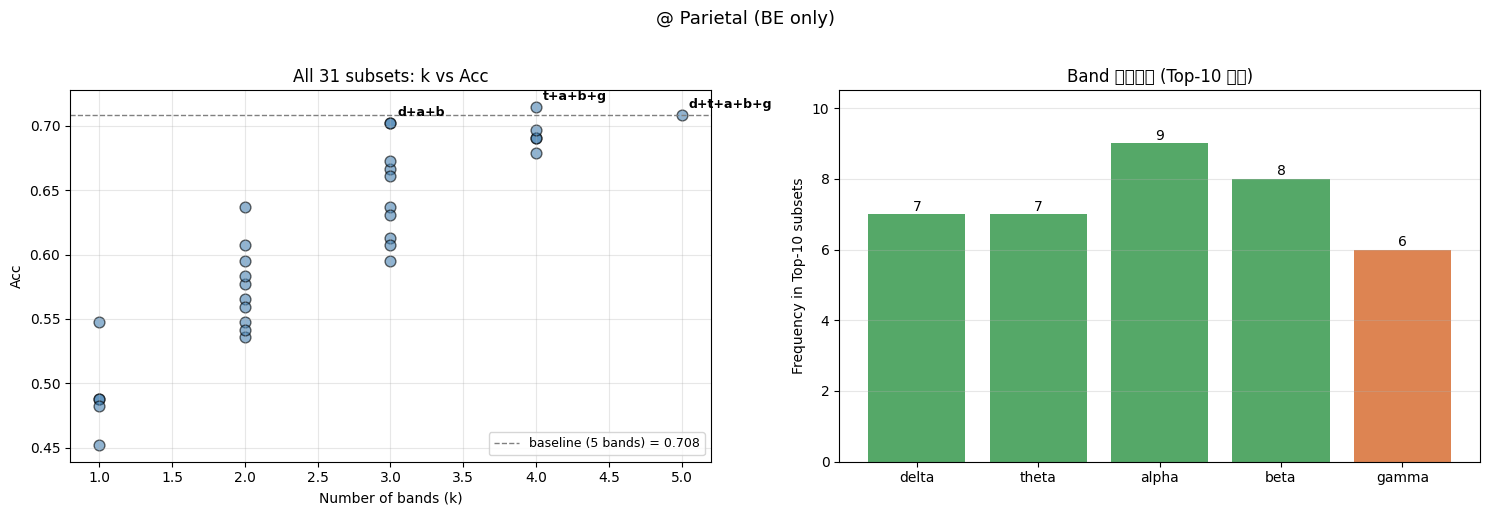

In [41]:
# ── 視覺化 2: 所有 31 子集 (k vs Acc) + band 出現頻率 ──
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Scatter: k vs Acc
ax = axes[0]
ks = [r['k'] for r in subset_results]
accs = [r['acc'] for r in subset_results]
ax.scatter(ks, accs, c='steelblue', s=60, alpha=0.6, edgecolors='black')
# 標註 top 3
for r in subset_results_sorted[:3]:
    ax.annotate('+'.join(b[0] for b in r['names']),
                (r['k'], r['acc']),
                textcoords='offset points', xytext=(5, 5),
                fontsize=9, weight='bold')
ax.axhline(baseline['acc'], color='gray', ls='--', lw=1,
           label=f'baseline (5 bands) = {baseline["acc"]:.3f}')
ax.set_xlabel('Number of bands (k)'); ax.set_ylabel('Acc')
ax.set_title('All 31 subsets: k vs Acc')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# Band 出現頻率 in top-10 subsets
ax = axes[1]
top10 = subset_results_sorted[:10]
band_count = {b: 0 for b in BAND_NAMES}
for r in top10:
    for name in r['names']:
        band_count[name] += 1
counts = [band_count[b] for b in BAND_NAMES]
colors2 = ['#55A868' if c >= 7 else '#DD8452' if c >= 4 else '#C44E52' for c in counts]
ax.bar(range(len(BAND_NAMES)), counts, color=colors2)
ax.set_xticks(range(len(BAND_NAMES))); ax.set_xticklabels(BAND_NAMES)
ax.set_ylabel('Frequency in Top-10 subsets')
ax.set_title('Band 出現頻率 (Top-10 子集)')
for i, c in enumerate(counts):
    ax.text(i, c + 0.1, str(c), ha='center', fontsize=10)
ax.set_ylim(0, 10.5)
ax.grid(axis='y', alpha=0.3)

plt.suptitle(f'@ {TARGET_REGION} (BE only)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(r'D:\Tseng\game_eeg\SVM_BE\svm_band_energy_subsets.png',
            dpi=150, bbox_inches='tight')
plt.show()